# **SpaceX  Falcon 9 First Stage Landing Prediction**


Note: This project utilizes a set of utility functions provided by IBM (e.g., get...Data, plot_confusion_matrix) to streamline data acquisition and visualization. All subsequent analysis, hyperparameter tuning, and model evaluation were performed independently.

# Part 1: EDA with Data Vizualization using Python

## Exploring and Preparing Data

Objective: Perform Exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`.

## Import Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis

First, let's read the SpaceX dataset into a Pandas dataframe and print its summary

In [2]:
df=pd.read_csv('Falcon9_pred_part_1.csv')
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


Let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.
We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch.

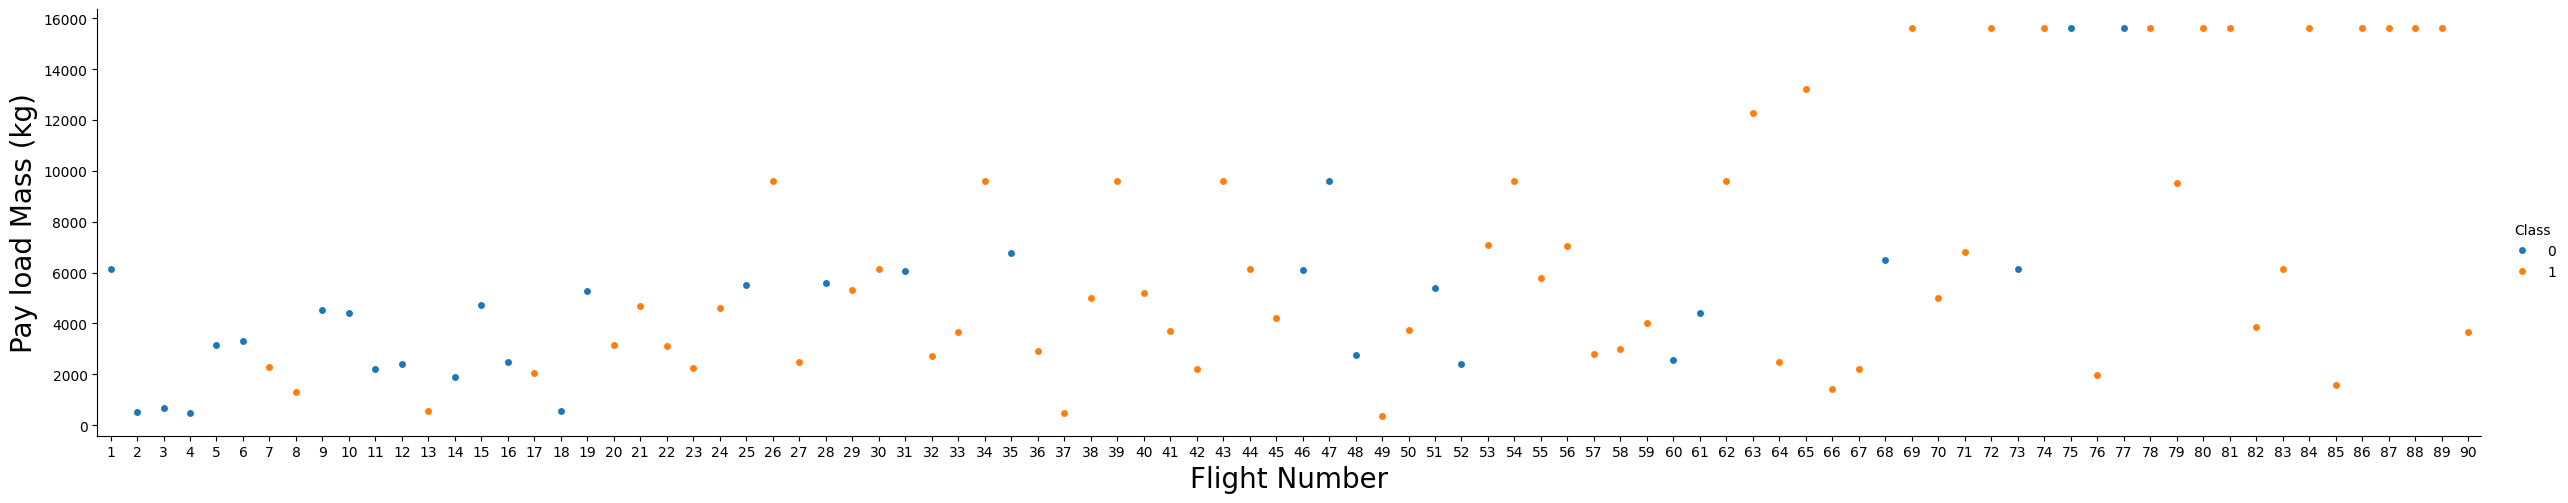

In [3]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage often returns successfully.

#### Let's visualize the relationship between Flight Number and Launch Site


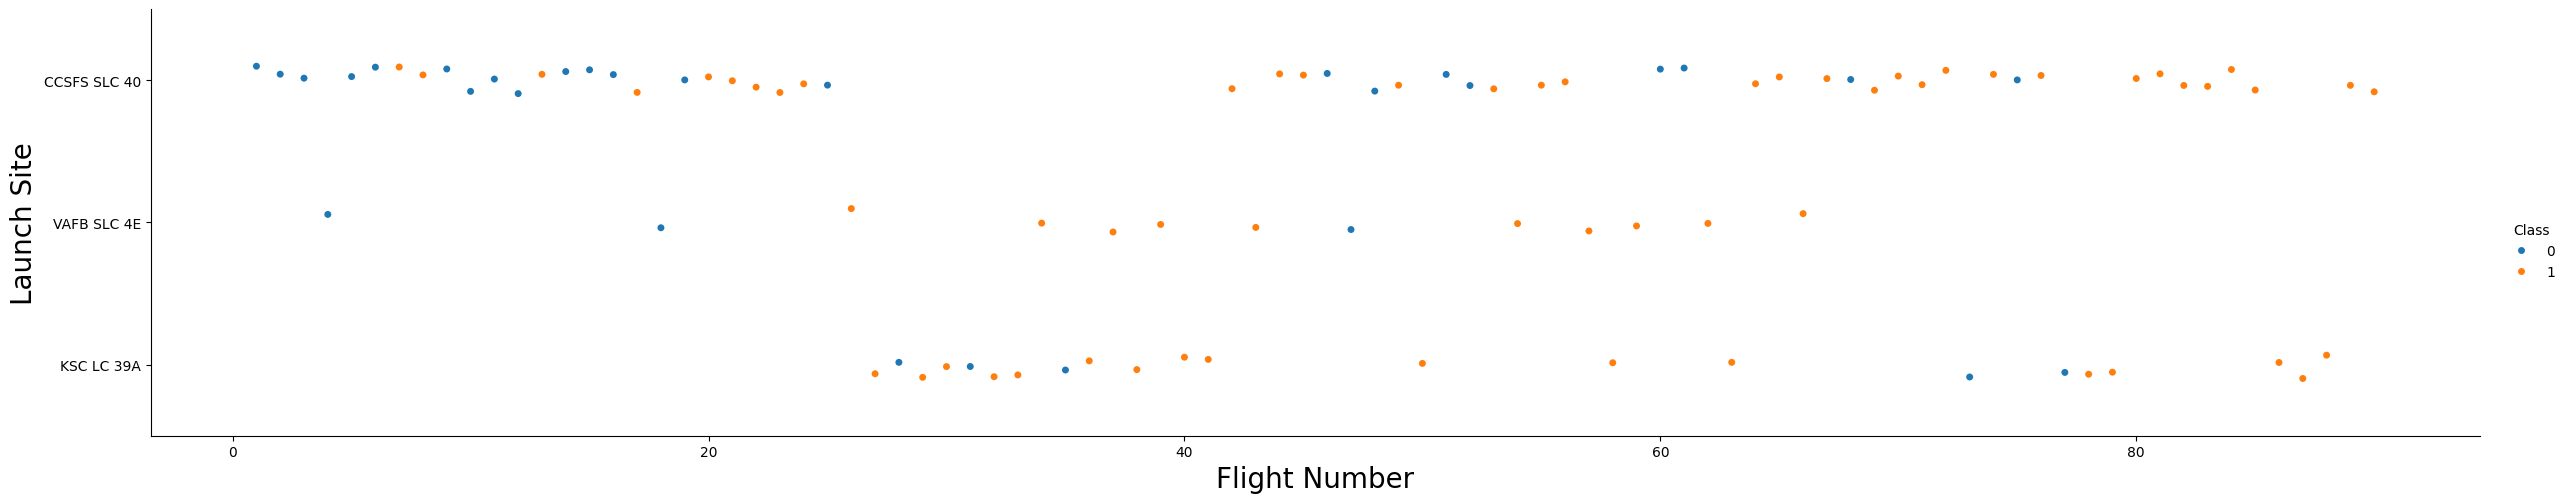

In [4]:
sns.catplot(x = 'FlightNumber', y='LaunchSite', hue = 'Class', data = df, aspect = 5)
plt.xlabel("Flight Number", fontsize = 20)
plt.ylabel("Launch Site", fontsize = 20)
plt.show()

* The Learning Curve: Early launches (lower flight numbers) primarily occurred at CCAFS LC-40 and exhibit a higher density of failed landings (blue dots), representing the initial experimental phase.
* Maturation of Technology: As flight numbers increase (moving right on the x-axis), the frequency of successful landings (orange dots) increases dramatically across all sites.
* Site Transition: There is a clear strategic shift mid-timeline to utilizing KSC LC-39A, which coincides with a nearly flawless landing success streak.


#### We also want to observe if there is any relationship between launch sites and their payload mass.
Visualize the relationship between Payload Mass and Launch Site

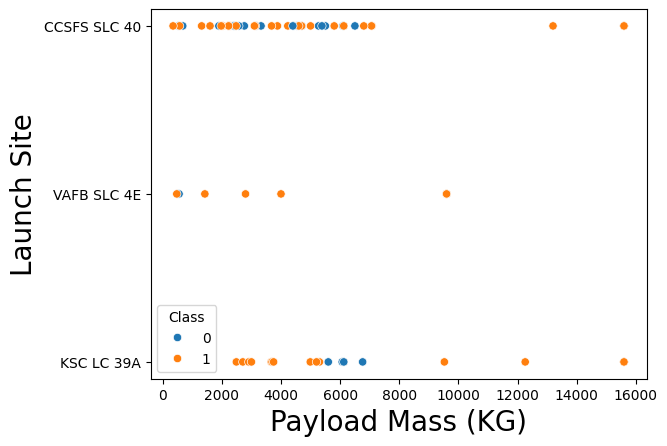

In [5]:
sns.scatterplot(x = 'PayloadMass',y='LaunchSite', hue = 'Class', data = df)
plt.xlabel("Payload Mass (KG)", fontsize = 20)
plt.ylabel("Launch Site", fontsize = 20)
plt.show()

* Site Capabilities: Observe that CCAFS LC-40 handles the widest variety of payload masses, ranging from very light to heavy, but has a mixed success rate with heavier loads.
* Heavy Lift Success: KSC LC-39A is predominantly used for heavier payloads and demonstrates a highly consistent success rate, suggesting optimized logistics for massive launches at this site.
* Payload Limits: VAFB SLC-4E is rarely used for extremely heavy payloads (above 10,000 kg), highlighting potential geographical or infrastructural constraints.


#### Next, we want to visually check if there are any relationship between success rate and orbit type. Visualize the relationship between success rate of each orbit type.

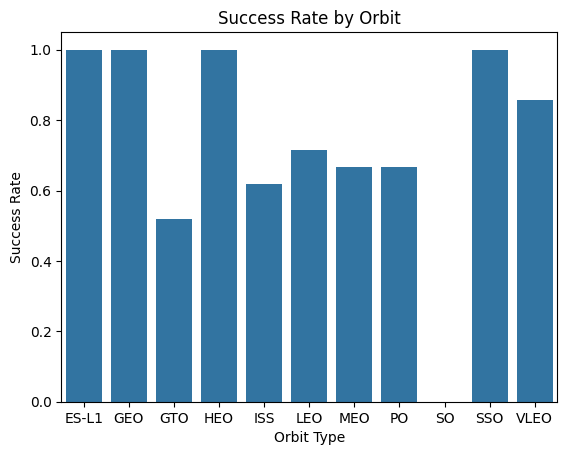

In [6]:
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()
sns.barplot(x='Orbit',y='Class', data = orbit_success)

plt.xlabel('Orbit Type')
plt.ylabel('Success Rate')
plt.title('Success Rate by Orbit')
plt.show()

* High-Success Orbits: Missions to ES-L1, GEO, HEO, and SSO show a perfect 100% success rate, making them prime candidates for predictable cost savings through reusability.
* Standard Performance: Low Earth Orbit (LEO) and Very Low Earth Orbit (VLEO) maintain strong success rates (above 70%-80%), benefiting from mature landing protocols.
* Variable Orbits: GTO (Geostationary Transfer Orbit) shows significantly lower success rates (approx 50%), likely due to the higher velocity and more challenging reentry conditions associated with these missions.


#### For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type. Visualize the relationship between FlightNumber and Orbit type


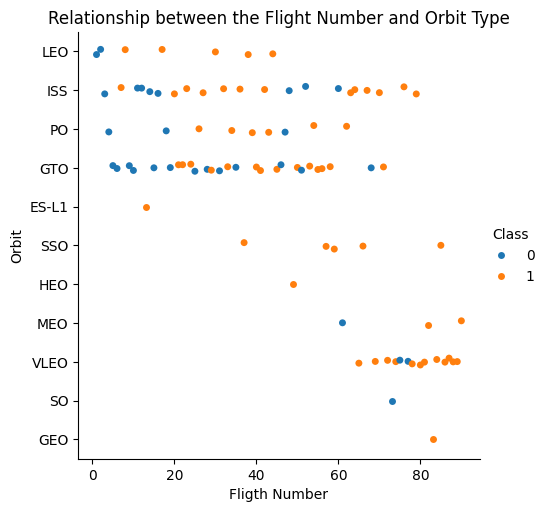

In [7]:
sns.catplot(x='FlightNumber',y='Orbit', hue = 'Class', data = df)

plt.xlabel('Fligth Number')
plt.ylabel('Orbit')
plt.title('Relationship between the Flight Number and Orbit Type')
plt.show()

* Evolution of Missions: Earlier flight numbers (0–40) were heavily concentrated in LEO, ISS, and GTO orbits. As experience grew (Flight 40+), SpaceX successfully expanded into diverse orbits like SSO, HEO, and MEO.
* Success Density: There is a visible increase in the density of successful orange points (Class 1) as flight numbers progress, particularly in the GTO and VLEO categories.
* Reliability Breakthrough: The plot demonstrates that as the company gained operational experience, they were able to maintain high landing success rates even while tackling more demanding orbital insertions.


#### Similarly, we can plot the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type. Visualize the relationship between Payload Mass and Orbit type


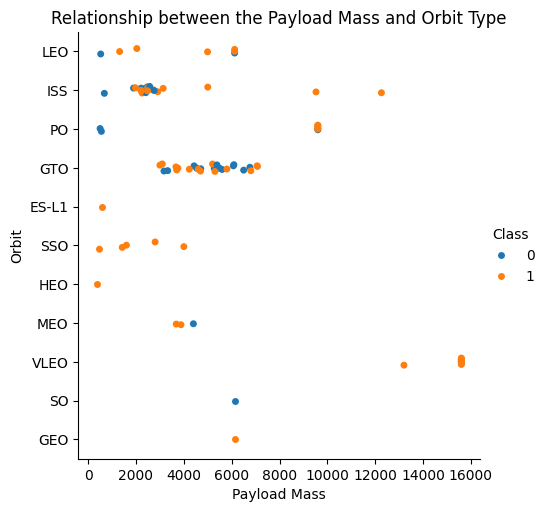

In [8]:
sns.catplot(x='PayloadMass',y='Orbit', hue = 'Class', data = df)
plt.xlabel('Payload Mass')
plt.ylabel('Orbit')
plt.title('Relationship between the Payload Mass and Orbit Type')
plt.show()

* Heavy Lift Success: In Low Earth Orbit (LEO) and Very Low Earth Orbit (VLEO), SpaceX demonstrates a high success rate even with maximum payloads exceeding 15,000 kg.
* GTO Variability: Launches to Geostationary Transfer Orbit (GTO) are concentrated around the 3,000–7,000 kg range. These missions show more variability in success outcomes due to higher reentry velocities.
* Specialized Orbits: High-altitude and specialized orbits like HEO, SSO, and ES-L1 generally handle lower payload masses (under 5,000 kg) and show a near-perfect landing record.


#### Let's now get the average launch success trend. For this, we will plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate.


In [9]:
# A function to Extract years from the date 
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


Text(0.5, 1.0, 'Yearly success rate trend')

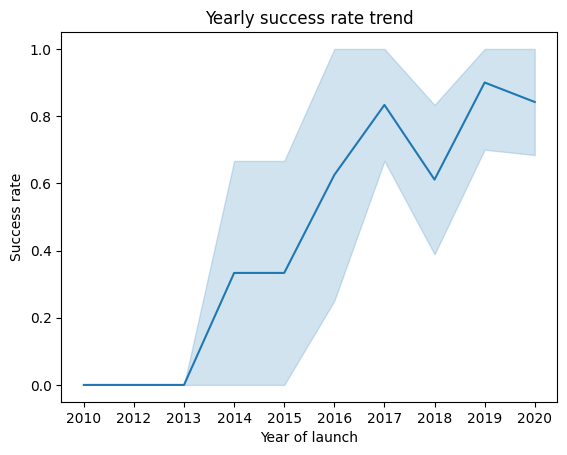

In [10]:
sns.lineplot(x = 'Date', y = 'Class', data = df)
plt.xlabel('Year of launch')
plt.ylabel('Success rate')
plt.title('Yearly success rate trend')

* The Experimental Era (2010–2013): Success rates remained at 0% as SpaceX focused on initial launch capabilities and flight telemetry rather than recovery.
* The Breakthrough (2014–2017): A sharp upward trend marks the period where SpaceX successfully landed its first boosters, rapidly iterating on its "Flight Combat" and landing leg technology.
* Operational Maturity (2018–2020): Success rates stabilized at a high level (approx 85%-90$), proving that reusability has transitioned from a risky experiment to a standard operational outcome.


## Features Engineering

By now, we have some prelimonary insights about the importance of each variable on the success rate so we can start selecting the features that we will use in the success prediction.

In [11]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6123.547647,LEO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


Let's create dummy variables to categorical columns

In [12]:
features_one_hot =pd.get_dummies(features, columns = ['Orbit','LaunchSite','LandingPad','Serial'])
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6123.547647,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


And cast all numeric columns <code>float64</code>

In [13]:
features_one_hot = features_one_hot.astype('float')
features_one_hot.dtypes

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 80, dtype: object

We can now export it to a <b>CSV</b> for the next task

In [14]:
features_one_hot.to_csv('dataset_hot_encoded.csv', index = False)

# Part 2: EDA with SQL

In [15]:
!pip install sqlalchemy==1.3.9

  Using cached sqlalchemy-1.3.9-cp313-cp313-win_amd64.whl
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.49
    Uninstalling SQLAlchemy-2.0.49:
      Successfully uninstalled SQLAlchemy-2.0.49


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.3.9 which is incompatible.


In [16]:
!pip install ipython-sql
!pip install ipython-sql prettytable

  Using cached sqlalchemy-2.0.49-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
Using cached sqlalchemy-2.0.49-cp313-cp313-win_amd64.whl (2.1 MB)
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 1.3.9
    Uninstalling SQLAlchemy-1.3.9:
      Successfully uninstalled SQLAlchemy-1.3.9


In [2]:
%load_ext sql

In [3]:
import csv, sqlite3
import prettytable
prettytable.DEFAULT = 'DEFAULT'

con = sqlite3.connect("my_data1.db")
cur = con.cursor()

In [4]:
%sql sqlite:///my_data1.db

In [5]:
import pandas as pd
df = pd.read_csv("Spacex.csv")
df.to_sql("SPACEXTBL", con, if_exists='replace', index=False,method="multi")

101

In [6]:
%sql DROP TABLE IF EXISTS SPACEXTABLE;

 * sqlite:///my_data1.db
Done.


[]

In [7]:
%sql create table SPACEXTABLE as select * from SPACEXTBL where Date is not null

 * sqlite:///my_data1.db
Done.


[]

##### Display the names of the unique launch sites  in the space mission


In [8]:
%sql select distinct("Launch_Site") from SPACEXTABLE

 * sqlite:///my_data1.db
Done.


Launch_Site
CCAFS LC-40
VAFB SLC-4E
KSC LC-39A
CCAFS SLC-40


#####  Display 5 records where launch sites begin with the string 'CCA' 


In [9]:
%%sql select * from SPACEXTABLE
where "Launch_Site" like 'CCA%'
LIMIT 5

 * sqlite:///my_data1.db
Done.


Date,Time (UTC),Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of Brouere cheese",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt


##### Display the total payload mass carried by boosters launched by NASA (CRS)


In [25]:
%%sql select sum("PAYLOAD_MASS__KG_") from SPACEXTABLE
where "Customer" = 'NASA (CRS)'

 * sqlite:///my_data1.db
Done.


sum(PAYLOAD_MASS__KG_)
45596


##### Display average payload mass carried by booster version F9 v1.1

In [26]:
%%sql select avg("PAYLOAD_MASS__KG_") from SPACEXTABLE
where "Booster_Version" like 'F9 v1.1%'

 * sqlite:///my_data1.db
Done.


avg(PAYLOAD_MASS__KG_)
2534.6666666666665


##### List the date when the first succesful landing outcome in ground pad was acheived.

In [27]:
%%sql select min("Date") from SPACEXTABLE
where "Landing_Outcome" == 'Success (ground pad)'

 * sqlite:///my_data1.db
Done.


min(Date)
2015-12-22


##### List the names of the boosters which have success in drone ship and have payload mass greater than 4000 but less than 6000

In [28]:
%%sql select "Booster_Version" from SPACEXTABLE
where "Landing_Outcome" == 'Success (drone ship)' 
    AND "PAYLOAD_MASS__KG_" BETWEEN 4001 and 5999

 * sqlite:///my_data1.db
Done.


Booster_Version
F9 FT B1022
F9 FT B1026
F9 FT B1021.2
F9 FT B1031.2



##### List the total number of successful and failure mission outcomes

In [29]:
%%sql select "Mission_Outcome", count(*) as "Total_Number" from SPACEXTABLE
group by "Mission_Outcome"

 * sqlite:///my_data1.db
Done.


Mission_Outcome,Total_Number
Failure (in flight),1
Success,98
Success,1
Success (payload status unclear),1



##### List all the booster_versions that have carried the maximum payload mass, using a subquery with a suitable aggregate function.

In [30]:
%%sql select "Booster_Version" from SPACEXTABLE
where "PAYLOAD_MASS__KG_" = (select max("PAYLOAD_MASS__KG_") from SPACEXTABLE)

 * sqlite:///my_data1.db
Done.


Booster_Version
F9 B5 B1048.4
F9 B5 B1049.4
F9 B5 B1051.3
F9 B5 B1056.4
F9 B5 B1048.5
F9 B5 B1051.4
F9 B5 B1049.5
F9 B5 B1060.2
F9 B5 B1058.3
F9 B5 B1051.6


##### List the records which will display the month names, failure landing_outcomes in drone ship ,booster versions, launch_site for the months in year 2015.

In [31]:
%%sql select substr("Date",6,2), "Landing_Outcome", "Booster_Version", "Launch_Site" 
    from SPACEXTABLE
    where "Landing_Outcome" = 'Failure (drone ship)' 
    AND substr("Date",0,5) = '2015'

 * sqlite:///my_data1.db
Done.


"substr(Date,6,2)",Landing_Outcome,Booster_Version,Launch_Site
01,Failure (drone ship),F9 v1.1 B1012,CCAFS LC-40
04,Failure (drone ship),F9 v1.1 B1015,CCAFS LC-40


##### Rank the count of landing outcomes (such as Failure (drone ship) or Success (ground pad)) between the date 2010-06-04 and 2017-03-20, in descending order.

In [32]:
%%sql select "Landing_Outcome", count(*) as "Total_Number"
    from SPACEXTABLE
    WHERE "Date" BETWEEN '2010-06-04' and '2017-03-20'
    GROUP BY "Landing_Outcome"
    ORDER BY count(*) DESC

 * sqlite:///my_data1.db
Done.


Landing_Outcome,Total_Number
No attempt,10
Success (drone ship),5
Failure (drone ship),5
Success (ground pad),3
Controlled (ocean),3
Uncontrolled (ocean),2
Failure (parachute),2
Precluded (drone ship),1
